### Interpretation

The extracted master dataset contains **6,439 QUIC flows** collected from five Google services: Google Docs, Google Drive, Google Music, Google Search, and YouTube. Each flow is represented using statistical features computed from packet-level information, including packet count, duration, packet sizes, upload/download statistics, throughput, and inter-arrival times.

The dataset consists of 19 attributes, including one categorical class label (Service) and multiple numerical flow descriptors. The descriptive statistics reveal substantial variability among flows, suggesting that different Google services exhibit distinct communication characteristics suitable for traffic classification.

In [1]:
import os
import glob
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from scipy.stats import kurtosis

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
dataset = r"C:\Users\parth\Downloads\UCDavis"

In [3]:
master_data = []

for service in os.listdir(dataset):
    service_path = os.path.join(dataset, service)
    if not os.path.isdir(service_path):
        continue
    txt_files = glob.glob(os.path.join(service_path, "*.txt"))
    for file in txt_files:
        try:
            df = pd.read_csv(
                file,
                sep="\t",
                header=None,
                names=[
                    "Timestamp",
                    "RelativeTime",
                    "PacketLength",
                    "Direction"
                ]
            )
            packet_count = len(df)
            duration = (
                df["RelativeTime"].iloc[-1]
                - df["RelativeTime"].iloc[0]
            )
            total_bytes = df["PacketLength"].sum()
            mean_packet = df["PacketLength"].mean()
            median_packet = df["PacketLength"].median()
            std_packet = df["PacketLength"].std()
            max_packet = df["PacketLength"].max()
            min_packet = df["PacketLength"].min()
            upload_packets = (df["Direction"] == 1).sum()
            download_packets = (df["Direction"] == 0).sum()
            upload_bytes = df[df.Direction==1]["PacketLength"].sum()
            download_bytes = df[df.Direction==0]["PacketLength"].sum()
            upload_ratio = upload_packets / packet_count
            download_ratio = download_packets / packet_count
            throughput = total_bytes / duration if duration > 0 else 0
            iat = df["RelativeTime"].diff().dropna()
            mean_iat = iat.mean()
            std_iat = iat.std()
            master_data.append({
                "Service": service,
                "Flow": os.path.basename(file),
                "Packets": packet_count,
                "Duration": duration,
                "TotalBytes": total_bytes,
                "MeanPacket": mean_packet,
                "MedianPacket": median_packet,
                "StdPacket": std_packet,
                "MaxPacket": max_packet,
                "MinPacket": min_packet,
                "UploadPackets": upload_packets,
                "DownloadPackets": download_packets,
                "UploadBytes": upload_bytes,
                "DownloadBytes": download_bytes,
                "UploadRatio": upload_ratio,
                "DownloadRatio": download_ratio,
                "Throughput": throughput,
                "MeanIAT": mean_iat,
                "StdIAT": std_iat
            })
        except:
            print(file)

In [4]:
master_df = pd.DataFrame(master_data)
master_df.head()

,Service,Flow,Packets,Duration,TotalBytes,MeanPacket,MedianPacket,StdPacket,MaxPacket,MinPacket,UploadPackets,DownloadPackets,UploadBytes,DownloadBytes,UploadRatio,DownloadRatio,Throughput,MeanIAT,StdIAT
0,Google Doc,GoogleDoc-100.txt,2925,116.348,816029,278.984274,148.0,331.901819,1412,80,1310,1615,421298,394731,0.447863,0.552137,7013.691684,0.039791,0.118710
1,Google Doc,GoogleDoc-1000.txt,2813,116.592,794628,282.484181,148.0,339.091353,1412,80,1256,1557,404564,390064,0.446498,0.553502,6815.459037,0.041462,0.154467
2,Google Doc,GoogleDoc-1001.txt,2440,116.929,714540,292.844262,148.0,351.052566,1412,80,1107,1333,384194,330346,0.453689,0.546311,6110.887804,0.047941,0.173467
3,Google Doc,GoogleDoc-1002.txt,2797,116.730,784079,280.328566,148.0,335.110186,1412,80,1230,1567,403484,380595,0.439757,0.560243,6717.030755,0.041749,0.149249
4,Google Doc,GoogleDoc-1003.txt,2504,115.723,701820,280.279553,148.0,341.984780,1412,80,1172,1332,355854,345966,0.468051,0.531949,6064.654390,0.046234,0.168468


In [5]:
print(master_df.shape)
master_df.info()
master_df.describe()

(6439, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6439 entries, 0 to 6438
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Service          6439 non-null   object 
 1   Flow             6439 non-null   object 
 2   Packets          6439 non-null   int64  
 3   Duration         6439 non-null   float64
 4   TotalBytes       6439 non-null   int64  
 5   MeanPacket       6439 non-null   float64
 6   MedianPacket     6439 non-null   float64
 7   StdPacket        6439 non-null   float64
 8   MaxPacket        6439 non-null   int64  
 9   MinPacket        6439 non-null   int64  
 10  UploadPackets    6439 non-null   int64  
 11  DownloadPackets  6439 non-null   int64  
 12  UploadBytes      6439 non-null   int64  
 13  DownloadBytes    6439 non-null   int64  
 14  UploadRatio      6439 non-null   float64
 15  DownloadRatio    6439 non-null   float64
 16  Throughput       6439 non-null   float64
 17  Mea

,Packets,Duration,TotalBytes,MeanPacket,MedianPacket,StdPacket,MaxPacket,MinPacket,UploadPackets,DownloadPackets,UploadBytes,DownloadBytes,UploadRatio,DownloadRatio,Throughput,MeanIAT,StdIAT
count,6439.000000,6439.000000,6.439000e+03,6439.000000,6439.000000,6439.000000,6439.000000,6439.000000,6439.000000,6439.000000,6.439000e+03,6.439000e+03,6439.000000,6439.000000,6.439000e+03,6439.000000,6439.000000
mean,6652.927473,42.924864,7.225949e+06,828.978629,810.120360,477.036163,1376.246312,79.869856,2002.383134,4650.544339,1.612653e+06,5.613296e+06,0.347311,0.652689,7.670088e+05,0.015447,0.128609
std,6195.895084,40.356444,7.750589e+06,379.930871,618.153017,103.414704,58.556838,8.217256,2624.069368,5226.165852,3.759767e+06,7.747564e+06,0.206617,0.206617,1.697489e+06,0.016944,0.087832
min,176.000000,0.240002,2.462500e+04,135.514019,92.000000,77.481528,341.000000,54.000000,64.000000,112.000000,8.191000e+03,1.610100e+04,0.092220,0.155645,2.413033e+03,0.000166,0.000710
25%,902.000000,10.644150,5.665575e+05,519.154771,148.000000,390.821320,1294.000000,74.000000,334.500000,572.000000,3.386700e+04,3.207280e+05,0.123941,0.552777,2.315888e+04,0.002751,0.077750
50%,5478.000000,24.727700,6.774431e+06,916.476000,1294.000000,449.124070,1412.000000,80.000000,995.000000,2155.000000,2.139750e+05,5.047090e+05,0.352459,0.647541,1.504249e+05,0.007313,0.127154
75%,10731.500000,61.329750,1.219748e+07,1239.806652,1412.000000,575.445347,1412.000000,84.000000,1903.000000,7221.000000,3.925030e+05,1.009090e+07,0.447223,0.876059,4.253442e+05,0.021938,0.168505
max,40021.000000,120.223000,4.949212e+07,1285.911359,1486.000000,687.055001,1486.000000,100.000000,10660.000000,34844.000000,1.477653e+07,4.882202e+07,0.844355,0.907780,7.713376e+06,0.100021,1.254244


### Interpretation

The missing value analysis indicates that **all extracted features are complete**, with zero missing values across every column. This confirms that the feature extraction process was successful and no additional preprocessing such as imputation is required before model development.

In [6]:
master_df.isnull().sum()

Service            0
Flow               0
Packets            0
Duration           0
TotalBytes         0
MeanPacket         0
MedianPacket       0
StdPacket          0
MaxPacket          0
MinPacket          0
UploadPackets      0
DownloadPackets    0
UploadBytes        0
DownloadBytes      0
UploadRatio        0
DownloadRatio      0
Throughput         0
MeanIAT            0
StdIAT             0
dtype: int64

### Interpretation

The class distribution illustrates the number of network flows available for each Google service. The dataset appears reasonably balanced across the five application classes, reducing the likelihood of significant class imbalance during supervised learning.

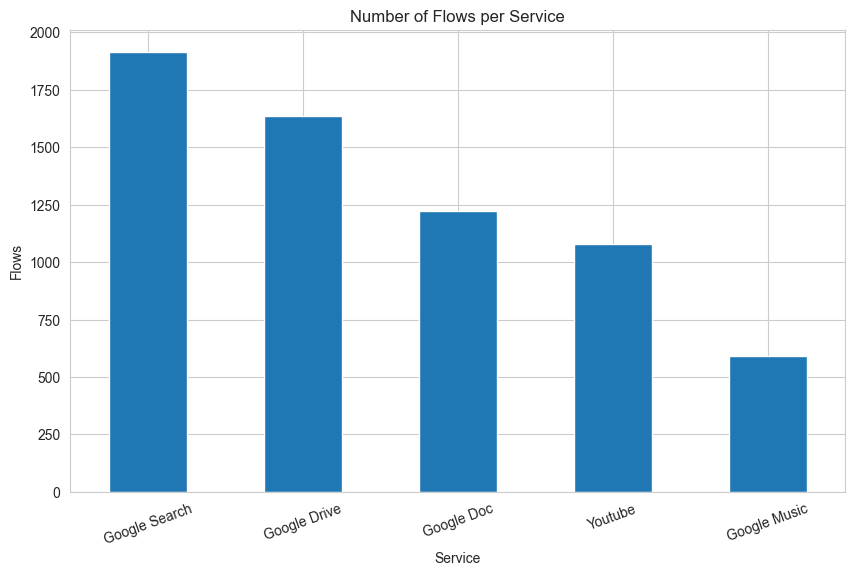

In [14]:
master_df["Service"].value_counts().plot.bar()
plt.title("Number of Flows per Service")
plt.xlabel("Service")
plt.xticks(rotation=20)
plt.ylabel("Flows")
plt.show()

### Interpretation

The packet count distribution is positively skewed, indicating that while many flows contain a moderate number of packets, some flows consist of substantially larger packet sequences. This behaviour is expected for modern network applications, where user interactions and multimedia streaming generate flows of varying lengths. The observed variability in counts suggests that packet count is likely to be an informative feature for distinguishing different QUIC applications.

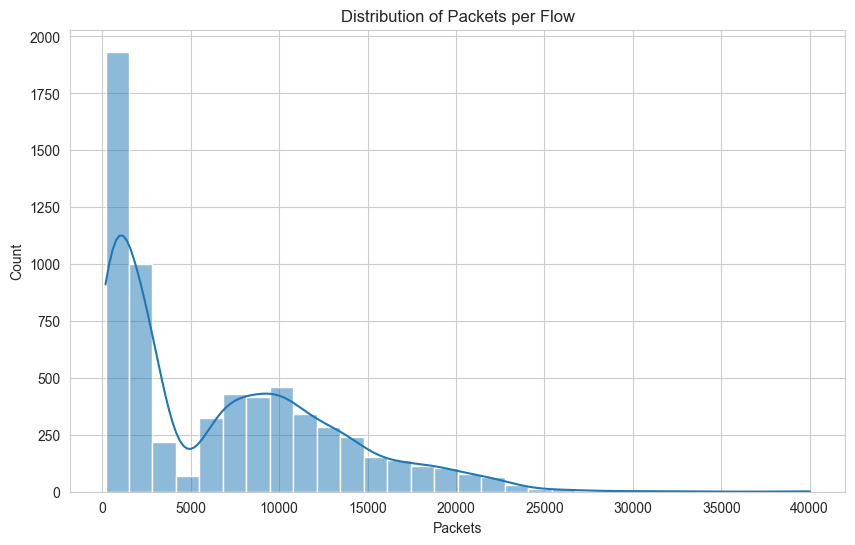

In [34]:
sns.histplot(master_df["Packets"], bins=30,kde=True)
plt.title("Distribution of Packets per Flow")
plt.show()

### Interpretation

Flow durations exhibit considerable variation across the dataset. Some applications generate short-lived transactions, whereas others maintain persistent communication sessions. This variation reflects the differing communication patterns of services such as document editing, search requests, cloud storage synchronization, music streaming, and video streaming, making flow duration a valuable discriminative feature.

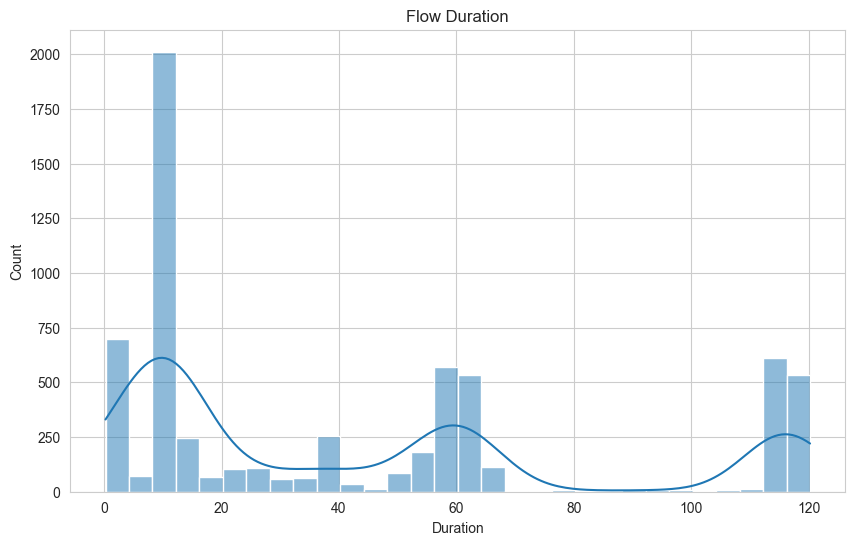

In [16]:
sns.histplot(master_df["Duration"], bins=30, kde=True)
plt.title("Flow Duration")
plt.show()

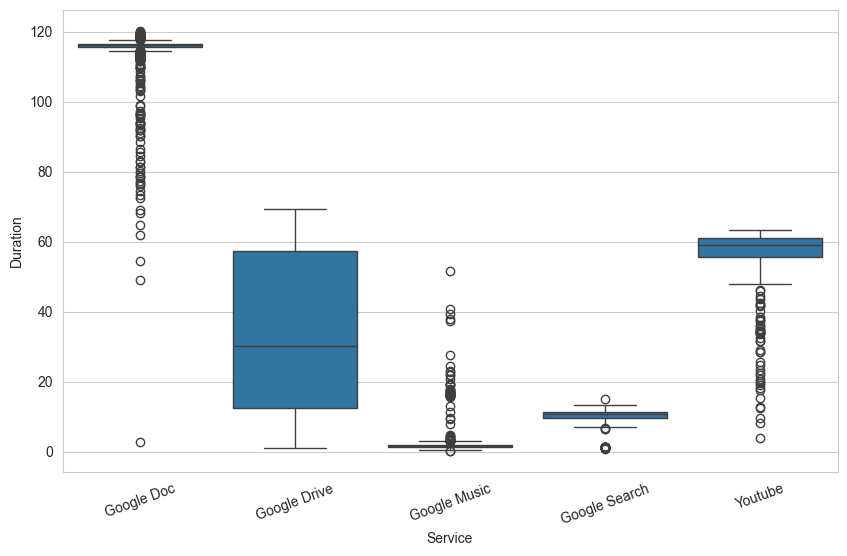

In [17]:
sns.boxplot(
    data=master_df,
    x="Service",
    y="Duration"
)
plt.xticks(rotation=20)
plt.show()

### Interpretation

The average packet size varies considerably among flows, indicating that different applications transmit data using distinct packetization strategies.
Applications responsible for transferring multimedia content generally produce larger average packet sizes, whereas lightweight interactive services generate comparatively smaller packets. This characteristic provides useful information for traffic classification.

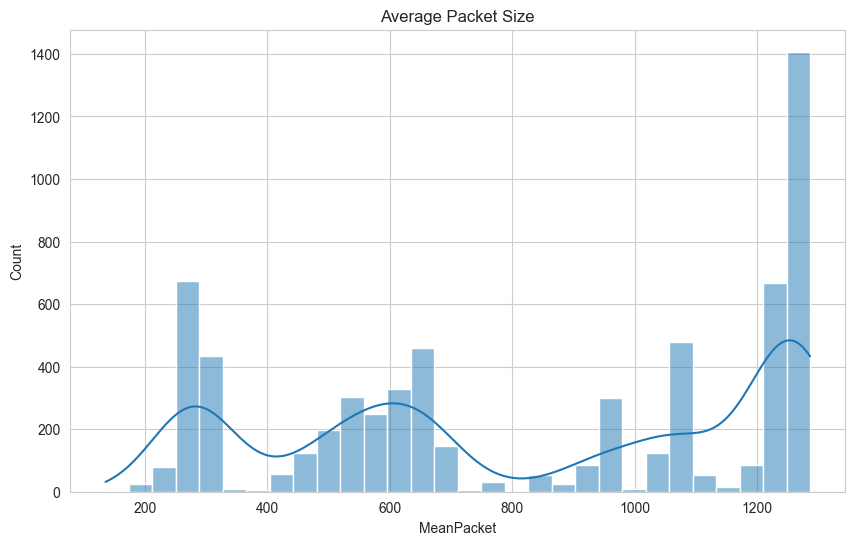

In [18]:
sns.histplot(master_df["MeanPacket"], bins=30, kde=True)
plt.title("Average Packet Size")
plt.show()

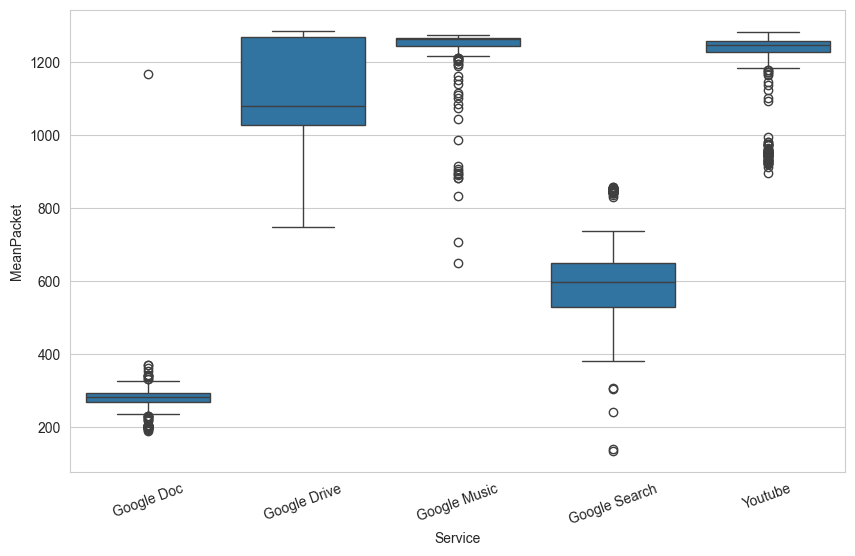

In [19]:
sns.boxplot(
    data=master_df,
    x="Service",
    y="MeanPacket"
)
plt.xticks(rotation=20)
plt.show()

### Interpretation

The total number of transmitted bytes spans a wide range of values, demonstrating that applications differ substantially in their communication volume. Large multimedia services like Youtube typically generate higher traffic volumes, whereas lightweight services transfer significantly fewer bytes. Consequently, total transferred bytes can serve as an effective indicator of application behaviour.

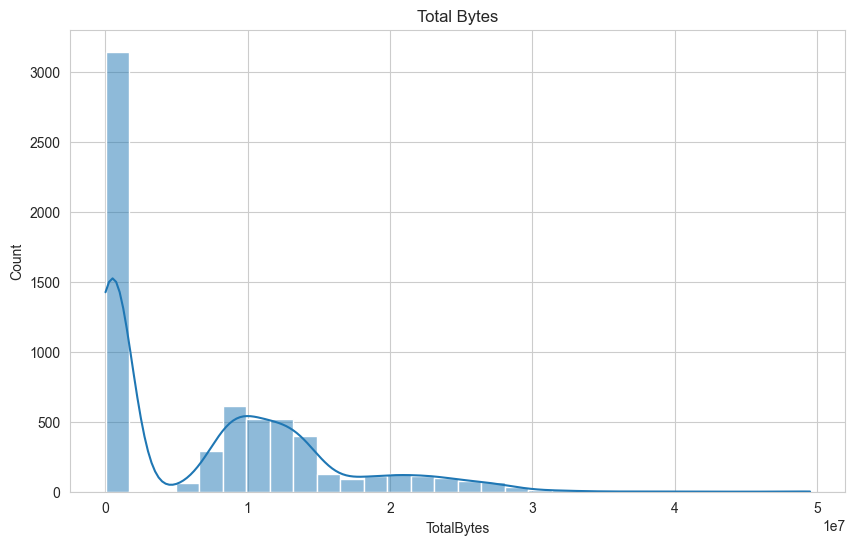

In [20]:
sns.histplot(master_df["TotalBytes"], bins=30, kde=True)
plt.title("Total Bytes")
plt.show()

### Interpretation

The throughput distribution indicates substantial differences in transmission rates among flows. Certain services sustain significantly higher data rates, while others operate with relatively low throughput. This behaviour reflects the bandwidth requirements of different applications and suggests that throughput is an important feature for distinguishing traffic generated by various Google services.

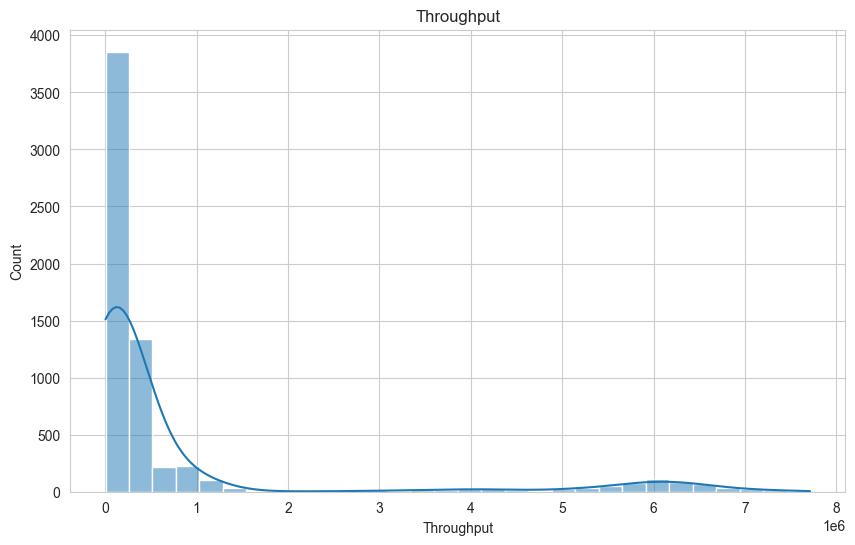

In [21]:
sns.histplot(master_df["Throughput"], bins=30, kde=True)
plt.title("Throughput")
plt.show()

### Interpretation

The upload ratio differs noticeably among the five services. Interactive applications generally transmit a larger proportion of client-generated packets, whereas content consumption services exhibit relatively low upload activity. These differences demonstrate that packet direction statistics capture meaningful behavioural characteristics and contribute useful discriminative information for traffic classification.

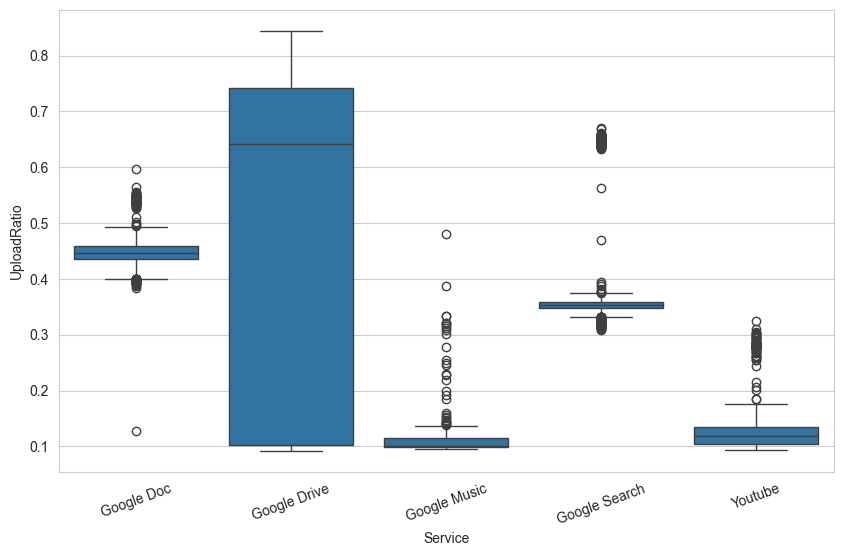

In [22]:
sns.boxplot(
    data=master_df,
    x="Service",
    y="UploadRatio"
)
plt.xticks(rotation=20)
plt.show()

### Interpretation

The download ratio complements the upload ratio by highlighting applications that primarily deliver content to the client.
Streaming applications such as YouTube and Google Music exhibit substantially higher download proportions, whereas collaborative services such as Google Docs and Google Drive maintain a more balanced communication pattern.

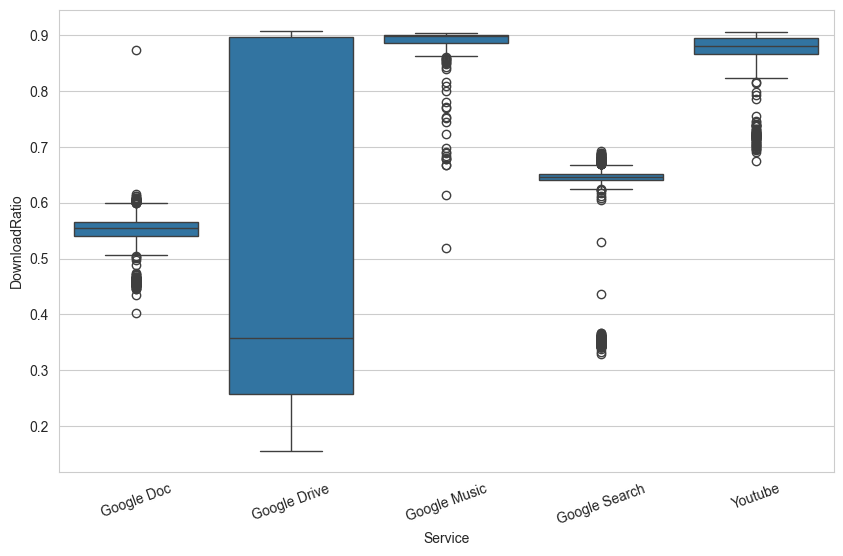

In [23]:
sns.boxplot(
    data=master_df,
    x="Service",
    y="DownloadRatio"
)
plt.xticks(rotation=20)
plt.show()

### Interpretation

The mean packet inter-arrival time varies across network flows, reflecting differences in packet generation frequency among applications.
Services requiring continuous data transmission generally exhibit shorter inter-arrival times, whereas interactive or request-response applications tend to produce larger intervals between consecutive packets.

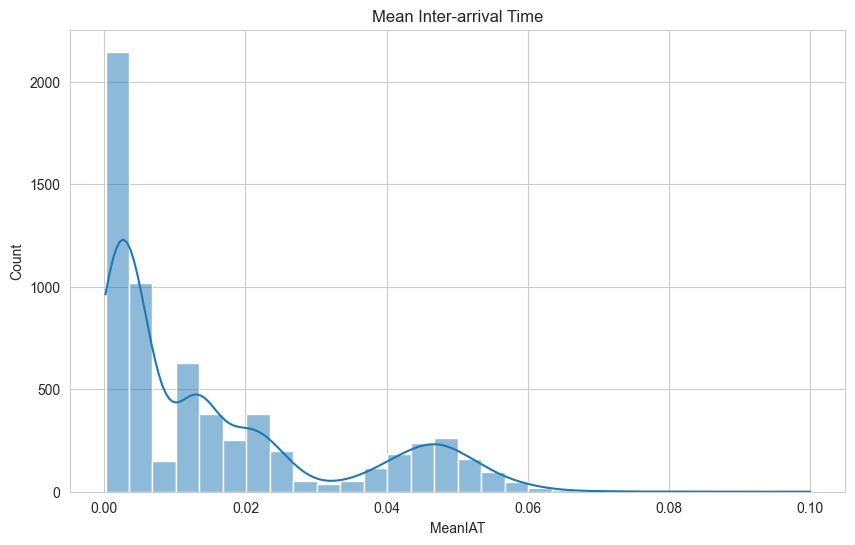

In [24]:
sns.histplot(master_df["MeanIAT"], bins=30,kde=True)
plt.title("Mean Inter-arrival Time")
plt.show()

### Interpretation

The variability in packet inter-arrival times differs significantly between applications. Higher standard deviations indicate bursty traffic behaviour, whereas lower values correspond to more stable transmission patterns.
These temporal characteristics provide additional information that can improve machine learning-based traffic classification.

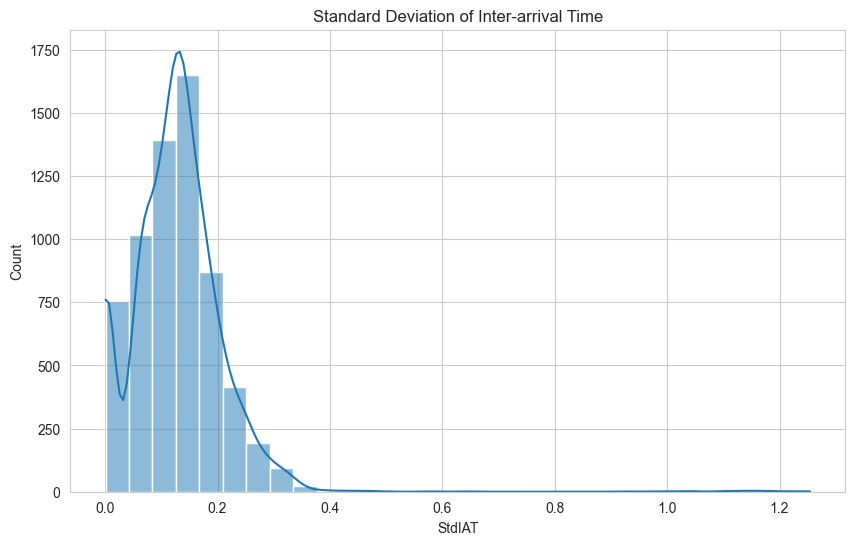

In [25]:
sns.histplot(master_df["StdIAT"], bins=30,kde=True)
plt.title("Standard Deviation of Inter-arrival Time")
plt.show()

### Interpretation

The correlation matrix reveals several strong relationships among the extracted features. Variables such as packet count, total bytes, and throughput demonstrate positive correlations because they describe related aspects of flow volume.
Conversely, upload and download ratios exhibit an inverse relationship due to their complementary definitions. The presence of correlated variables suggests that feature selection or dimensionality reduction techniques may further improve model efficiency.

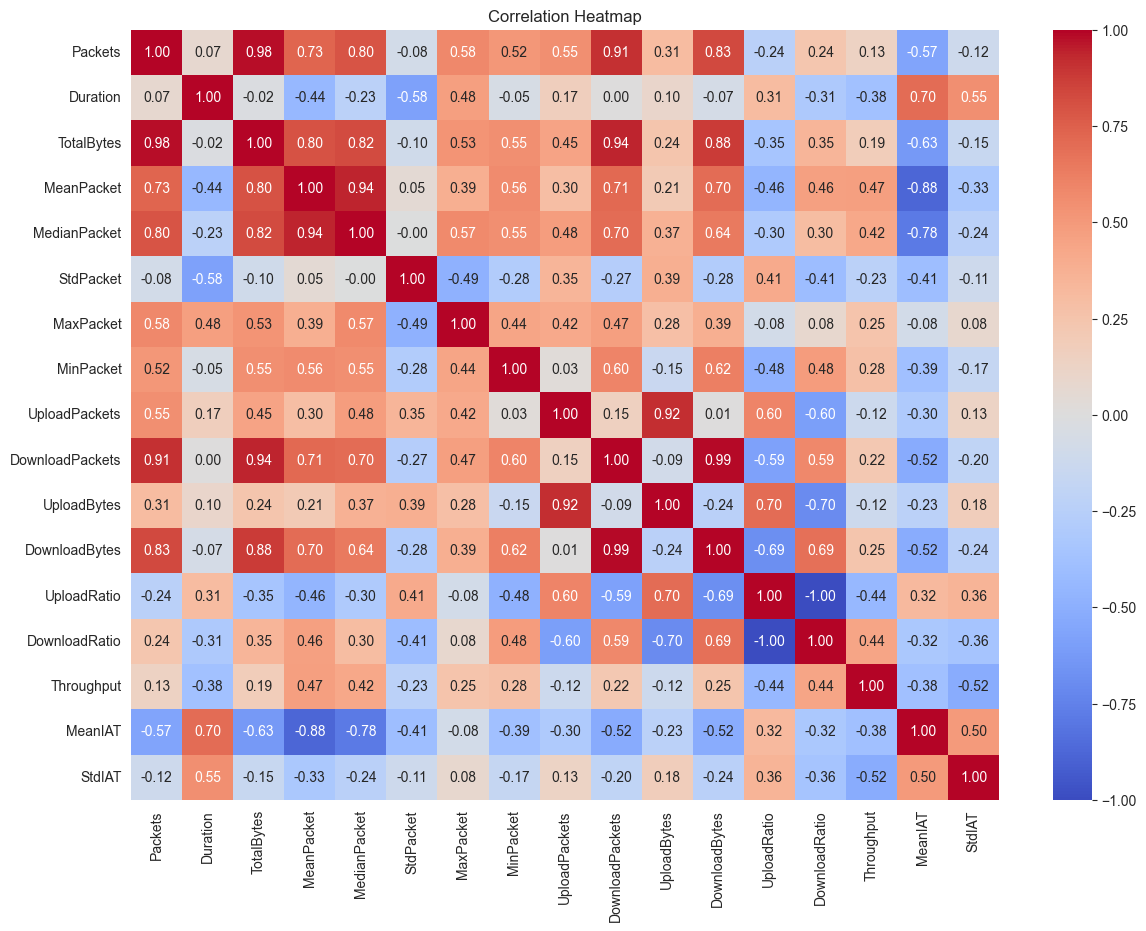

In [26]:
numeric = master_df.select_dtypes(include=np.number)
corr = numeric.corr()
plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

### Interpretation

The pairwise feature visualization provides insight into the separability of application classes. Several feature combinations show partial clustering of individual services, indicating that different applications occupy distinct regions of the feature space.
Although some overlap exists, the observed separation suggests that machine learning algorithms should be capable of learning effective decision boundaries using the extracted statistical features.

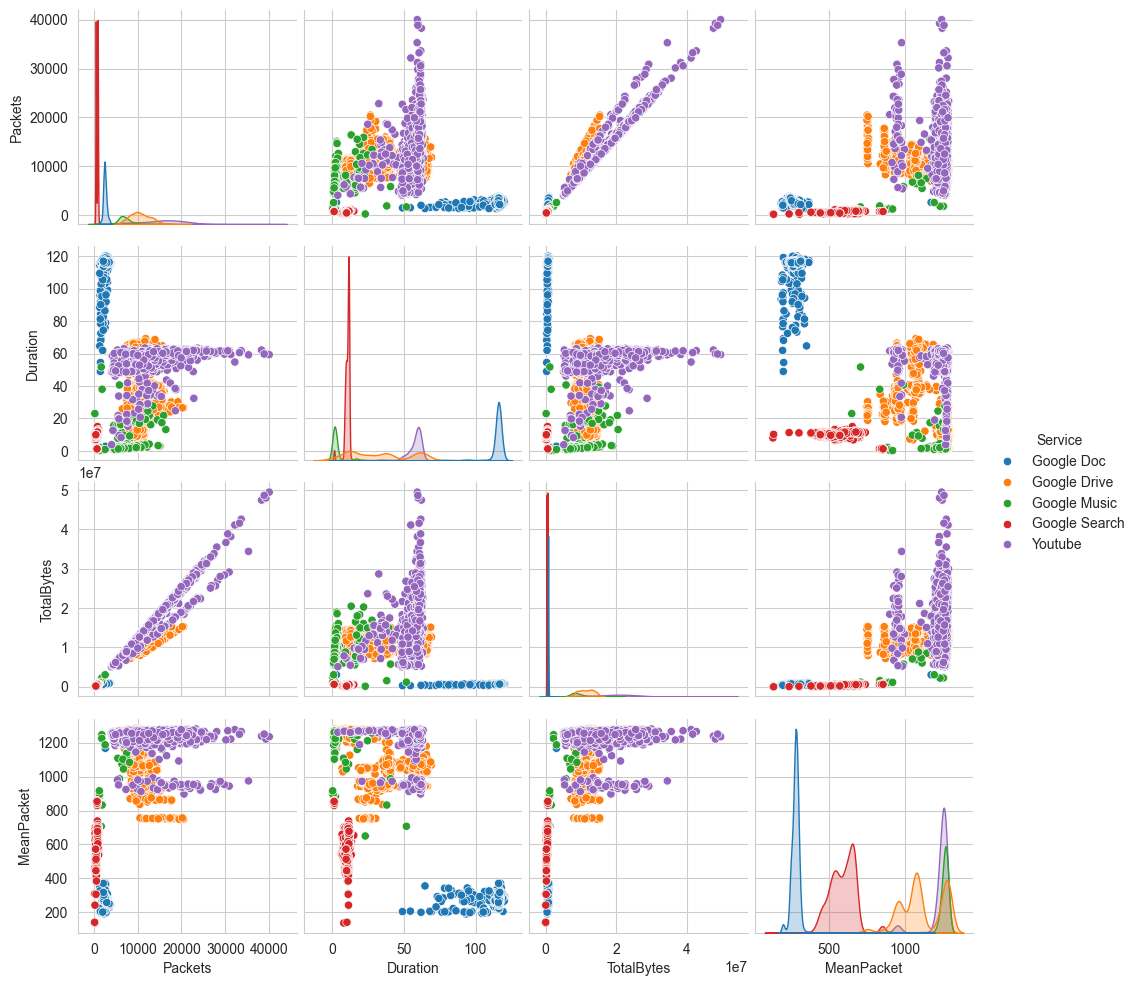

In [27]:
sns.pairplot(
    master_df,
    hue="Service",
    vars=[
        "Packets",
        "Duration",
        "TotalBytes",
        "MeanPacket"
    ]
)

### Interpretation

The service-wise summary shows clear behavioural differences among Google applications.

- Google Docs generates comparatively long-duration flows with moderate packet sizes and balanced bidirectional communication.
- Google Drive produces high-volume traffic due to cloud storage synchronization and file transfers.
- Google Music primarily consists of download-dominated flows with large average packet sizes.
- Google Search generates relatively short flows containing fewer packets and lower traffic volumes.
- YouTube produces the largest flows, highest traffic volumes, and predominantly download-oriented communication because of continuous video streaming.

In [28]:
master_df.groupby("Service").mean(numeric_only=True)

,Packets,Duration,TotalBytes,MeanPacket,MedianPacket,StdPacket,MaxPacket,MinPacket,UploadPackets,DownloadPackets,UploadBytes,DownloadBytes,UploadRatio,DownloadRatio,Throughput,MeanIAT,StdIAT
Service,,,,,,,,,,,,,,,,,
Google Doc,2514.097461,114.588044,7.017765e+05,280.884043,136.340295,340.237976,1410.639640,76.637183,1145.192465,1368.904996,3.532567e+05,3.485198e+05,0.454368,0.545632,6.978600e+03,0.046567,0.197532
Google Drive,10574.777846,32.715451,1.149180e+07,1105.330146,1388.071603,527.567450,1414.564259,83.195226,5095.269890,5479.507956,5.780863e+06,5.710934e+06,0.456385,0.543615,9.142739e+05,0.003080,0.115619
Google Music,7095.506757,3.164432,8.893955e+06,1247.066663,1405.369932,412.696359,1409.327703,82.969595,775.832770,6319.673986,1.009417e+05,8.793013e+06,0.112925,0.887075,5.031633e+06,0.000661,0.018675
Google Search,666.390078,10.331293,4.038586e+05,588.634836,228.105222,569.539948,1293.415666,73.958225,260.361358,406.028721,7.334305e+04,3.305156e+05,0.381623,0.618377,4.686857e+04,0.017110,0.116232
Youtube,15796.307335,56.978996,1.936380e+07,1228.621488,1404.813370,426.346174,1408.215413,87.297122,2053.397400,13742.909935,2.845002e+05,1.907929e+07,0.128280,0.871720,3.415464e+05,0.004102,0.152611


### Interpretation

The violin plot highlights both the distribution and density of packet counts for each application.
While some overlap exists among services, the overall distributions differ considerably, indicating that packet count captures application-specific communication behaviour. The presence of distinct density patterns suggests that packet-based statistical features are informative for classification tasks.

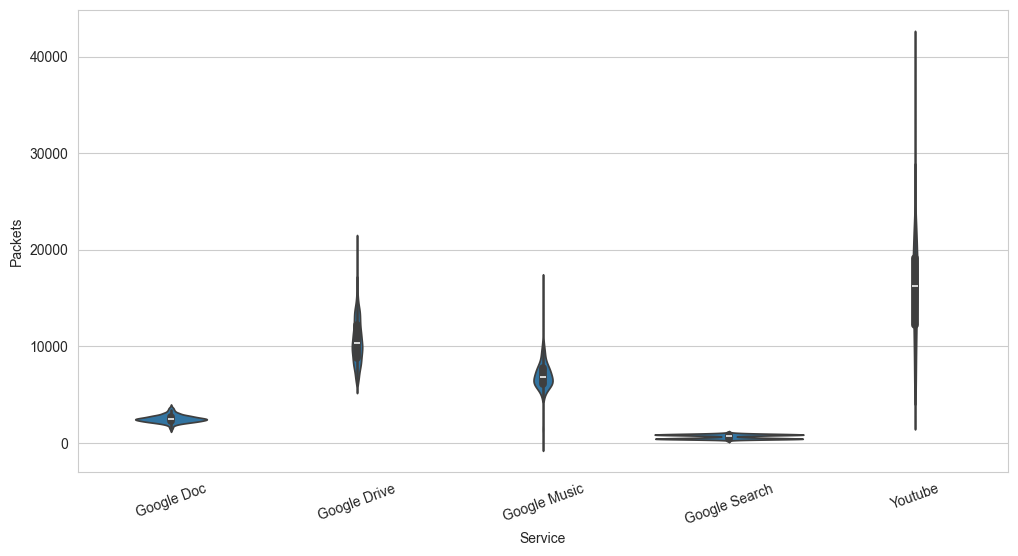

In [36]:
plt.figure(figsize=(12,6))
sns.violinplot(
    data=master_df,
    x="Service",
    y="Packets"
)
plt.xticks(rotation=20)
plt.show()

### Interpretation

Outlier analysis identifies flows whose packet counts differ substantially from the majority of observations.
Such flows may correspond to unusually long user sessions, large file transfers, or exceptional streaming activities. Since these observations represent realistic network behaviour rather than measurement errors, they should be retained unless subsequent modelling demonstrates that they adversely affect classifier performance.

In [30]:
Q1 = master_df["Packets"].quantile(0.25)
Q3 = master_df["Packets"].quantile(0.75)
IQR = Q3 - Q1
outliers = master_df[
    (master_df["Packets"] < Q1 - 1.5*IQR) |
    (master_df["Packets"] > Q3 + 1.5*IQR)
]
outliers

,Service,Flow,Packets,Duration,TotalBytes,MeanPacket,MedianPacket,StdPacket,MaxPacket,MinPacket,UploadPackets,DownloadPackets,UploadBytes,DownloadBytes,UploadRatio,DownloadRatio,Throughput,MeanIAT,StdIAT
5401,Youtube,Youtube-1035.txt,38268,62.1963,47460576,1240.215742,1412.0,430.778561,1412,90,4778,33490,625184,46835392,0.124856,0.875144,763077.160538,0.001625,0.052115
5621,Youtube,Youtube-251.txt,27235,60.2438,33390570,1226.016890,1412.0,443.668264,1412,85,3783,23452,562113,32828457,0.138902,0.861098,554257.367563,0.002212,0.082903
5637,Youtube,Youtube-267.txt,25848,59.1698,32067777,1240.628946,1412.0,431.883571,1412,92,3244,22604,414918,31652859,0.125503,0.874497,541961.896102,0.002289,0.080553
5643,Youtube,Youtube-273.txt,30881,61.8079,29174416,944.736764,1294.0,550.860919,1364,74,8810,22071,675763,28498653,0.285289,0.714711,472017.589984,0.002002,0.085468
5654,Youtube,Youtube-284.txt,35296,59.2293,34423191,975.271731,1294.0,535.360817,1351,74,9192,26104,711009,33712182,0.260426,0.739574,581185.173554,0.001678,0.063654
5656,Youtube,Youtube-286.txt,31251,59.4382,38194157,1222.173914,1412.0,452.615460,1412,88,4420,26831,563881,37630276,0.141435,0.858565,642586.030533,0.001902,0.070885
5680,Youtube,Youtube-31.txt,25900,61.6253,32169741,1242.074942,1412.0,430.575563,1412,89,3247,22653,424095,31745646,0.125367,0.874633,522021.653444,0.002379,0.094815
5711,Youtube,Youtube-338.txt,32172,54.7810,41131367,1278.483371,1412.0,383.908910,1412,90,3044,29128,400592,40730775,0.094616,0.905384,750832.715723,0.001703,0.066921
5729,Youtube,Youtube-354.txt,39266,59.9020,48012902,1222.760200,1412.0,452.785877,1412,91,5494,33772,667876,47345026,0.139917,0.860083,801524.189510,0.001526,0.046534
5762,Youtube,Youtube-384.txt,26045,58.4985,32448880,1245.877520,1412.0,422.925963,1412,85,3217,22828,474324,31974556,0.123517,0.876483,554695.932374,0.002246,0.082735


### Interpretation

The statistical summary indicates that most numerical features exhibit positive skewness, meaning that relatively few large flows increase the upper tails of the distributions.
The observed kurtosis values suggest that several features contain heavy-tailed distributions, which is common in real-world network traffic datasets. These characteristics justify the use of robust machine learning models capable of handling non-Gaussian feature distributions.

In [32]:
for col in [
    "Packets",
    "Duration",
    "TotalBytes",
    "MeanPacket",
    "Throughput",
    "MeanIAT"
]:
    print(col)
    print("Mean :", master_df[col].mean())
    print("Median :", master_df[col].median())
    print("Std :", master_df[col].std())
    print("Skew :", skew(master_df[col]))
    print("Kurtosis :", kurtosis(master_df[col]))

Packets
Mean : 6652.927473210126
Median : 5478.0
Std : 6195.895083634614
Skew : 0.9335298159356756
Kurtosis : 0.4192438414922388
Duration
Mean : 42.924863562354396
Median : 24.7277
Std : 40.356444161476325
Skew : 0.8006877390518348
Kurtosis : -0.7568453105654429
TotalBytes
Mean : 7225948.791271937
Median : 6774431.0
Std : 7750589.009106122
Skew : 0.9772069664238197
Kurtosis : 0.531691536338808
MeanPacket
Mean : 828.9786292301179
Median : 916.476
Std : 379.9308714094937
Skew : -0.17349050470662666
Kurtosis : -1.5316996495247772
Throughput
Mean : 767008.8121375602
Median : 150424.85318001345
Std : 1697488.751157692
Skew : 2.6955899527463036
Kurtosis : 5.767835279996772
MeanIAT
Mean : 0.015447269972389373
Median : 0.007313100243416685
Std : 0.016943751554442627
Skew : 1.1720459514048271
Kurtosis : 0.18532941852849616


## Conclusion

The EDA demonstrates that the UCDavis QUIC dataset contains diverse traffic characteristics across five Google services. The extracted flow-level statistical features reveal significant differences in packet count, flow duration, packet size, throughput, upload/download behaviour, and packet timing.

No missing values were observed, indicating a clean and complete dataset suitable for firther analysis. Service-wise comparisons show that each application exhibits unique communication patterns, supporting the hypothesis that statistical flow features can effectively distinguish QUIC traffic generated by different applications.

The correlation analysis further indicates meaningful relationships among several flow descriptors, while pairwise visualizations reveal noticeable class separability. Collectively, these findings confirm that the extracted statistical features provide a strong foundation for feature engineering, dimensionality reduction, and supervised machine learning models aimed at QUIC application classification.